In [22]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# Exercise 1: Visualizing the Invisible 
## Machine Learning as a Tool for Multi-Dimensional Data

In the lecture, we discussed how problems across various engineering disciplines can often be categorized as **Function Approximation** or **Classification**. We also discussed how Machine Learning algorithms essentially act as tools to help us "visualize" and understand data when it spans more dimensions than our human brains can comprehend.

**The Scenario:** Imagine you are an engineer tasked with predicting the physical expansion of a newly synthesized composite material. 

---
### Step 1: The 2D Function Approximation (What we can see)

**What the code below does:** We use `numpy` to simulate some real-world, slightly noisy sensor data for temperature and expansion. We then pack this data into a `pandas` DataFrame (which is essentially a powerful spreadsheet in Python) and use `plotly` to draw an interactive 2D scatter plot.

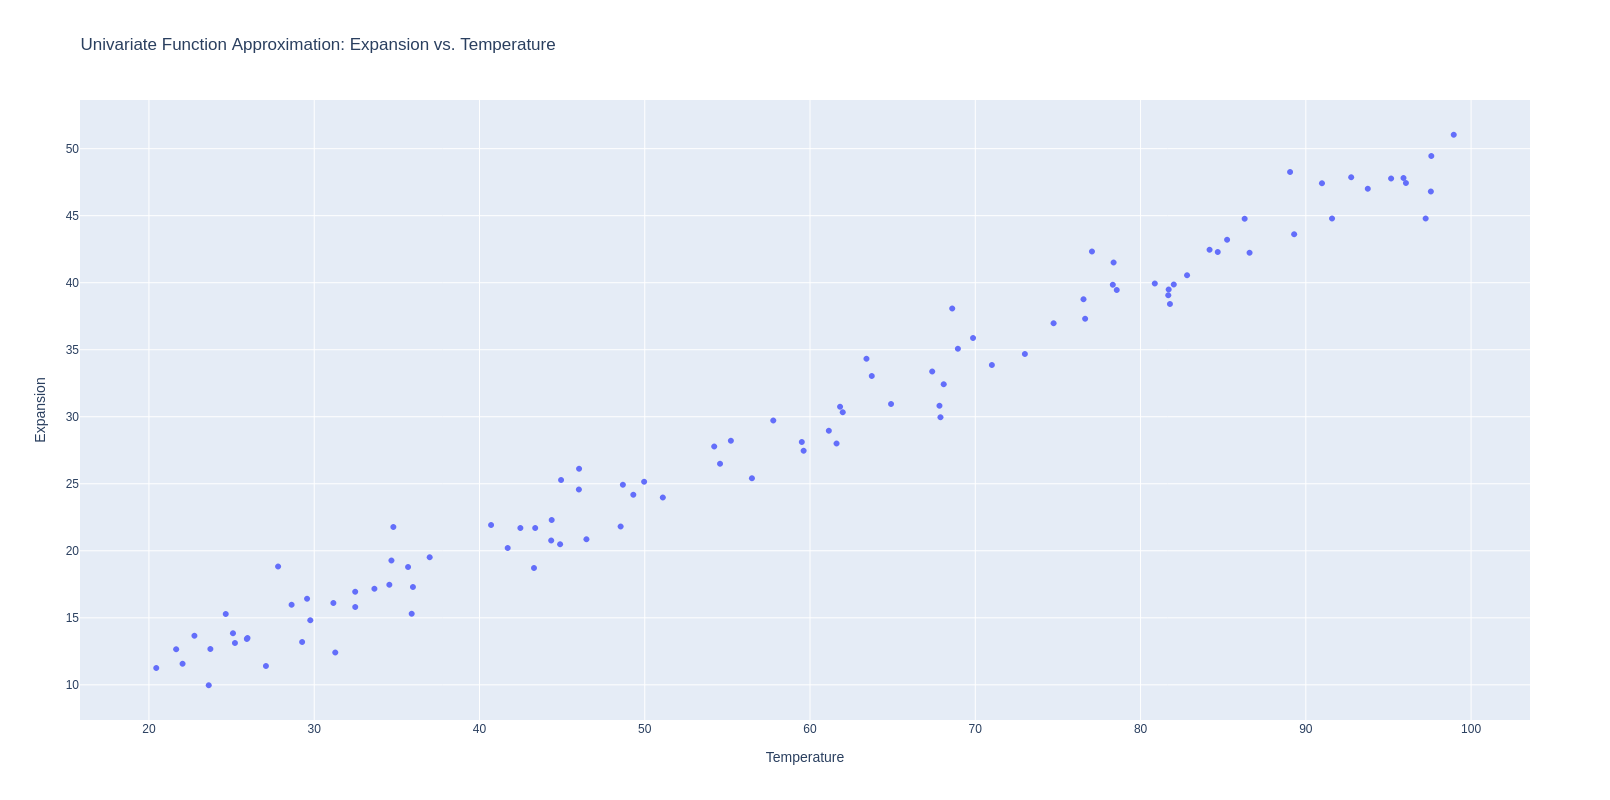

In [50]:
# 1. Generate 2D Data (1 Feature, 1 Output)
np.random.seed(42)
temperature = np.random.uniform(20, 100, 100)
# The true physical relationship:
expansion = 0.5 * temperature + np.random.normal(0, 2, 100)
# or use make_regression from scikit... only difference is that the output of make_regression is normalized between -1 and 1
# temperature, expansion = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)

df_2d = pd.DataFrame(
    {
        "Temperature": temperature.flatten(),
        "Expansion": expansion.flatten(),
    }
)

# 2. Plotly Interactive 2D Plot
fig_2d = px.scatter(
    df_2d,
    x="Temperature",
    y="Expansion",
    title="Univariate Function Approximation: Expansion vs. Temperature",
)
fig_2d.update_layout(
    height=800,
    width=800,
)
fig_2d.show()

### What can we see?
Take a look at the plot above. As engineers, if we want to approximate this function, our eyes immediately do the math. We can clearly see a linear relationship. If we wanted to draw a line of best fit, we could easily do it by hand. 

Because we only have **two dimensions** (one independent variable `u` and one dependent variable `y`), human visualization is perfectly sufficient to characterize the data.

---
### Step 2: The Multi-Dimensional Challenge (Where human vision breaks)

Let's say our material is much more complex. Expansion doesn't just depend on temperature; it depends on 1D descriptors, 2D angles, and 3D volumes. 

**What the code below does:** We use a handy tool from `scikit-learn` called `make_regression` to instantly generate a synthetic dataset with 5 input features. We then attempt to visualize this data using a 3D scatter plot. We map three inputs to the X, Y, and Z axes, and a fourth input to the color of the dots.

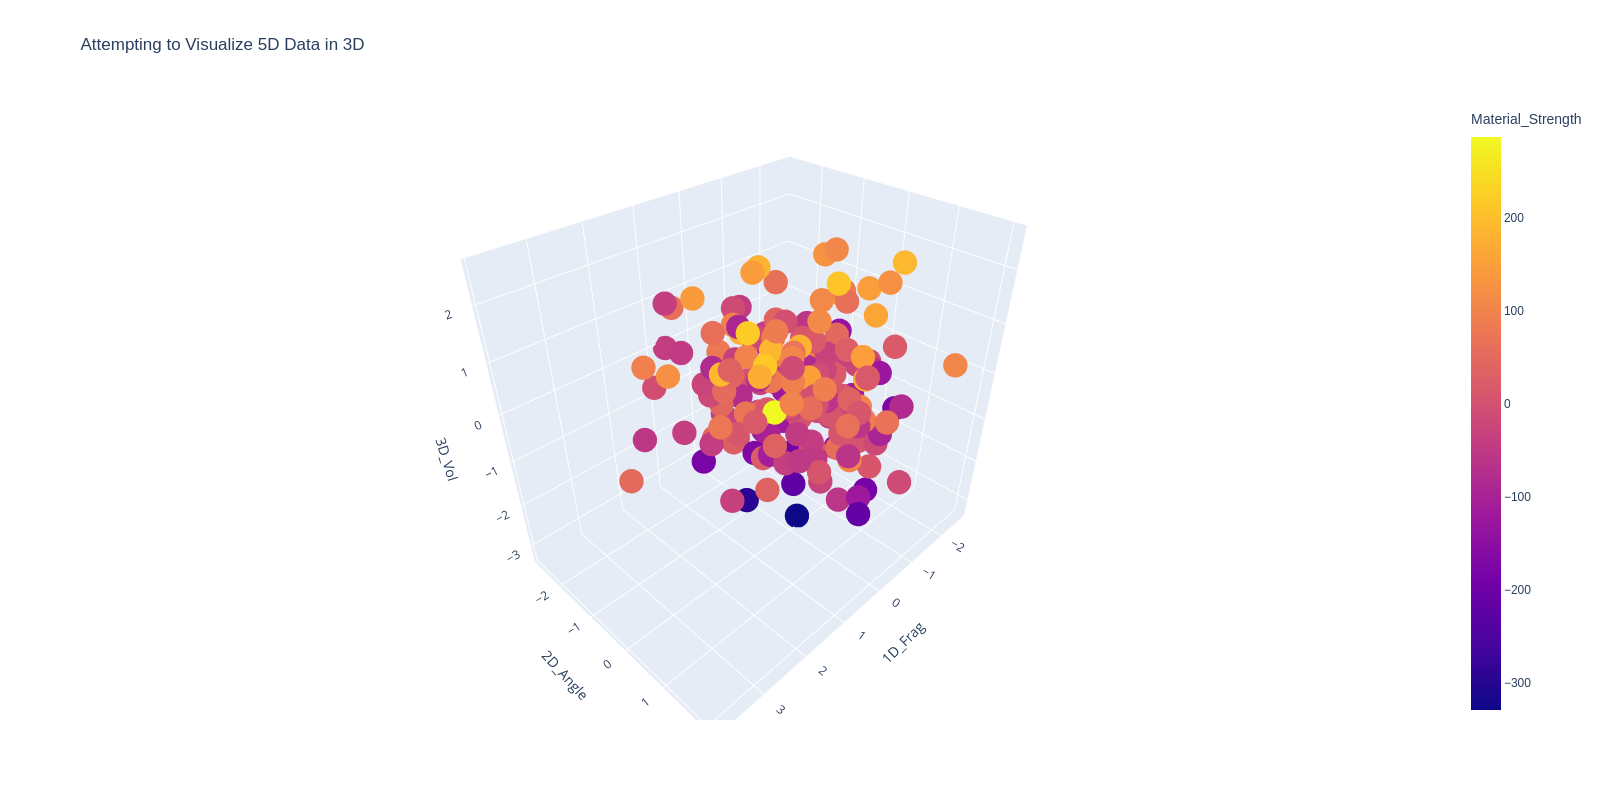

In [44]:
# Let's say our material is more complex. Expansion depends on 5 different features.
# We generate a dataset with 5 inputs and 1 output.
X, y = make_regression(n_samples=200, n_features=5, noise=15, random_state=42)
df_multi = pd.DataFrame(X, columns=["1D_Frag", "2D_Angle", "3D_Vol", "Density", "Temp"])
df_multi["Material_Strength"] = y

# 2. Attempt to visualize using a 3D plot
fig_3d = px.scatter_3d(
    df_multi,
    x="1D_Frag",
    y="2D_Angle",
    z="3D_Vol",
    color="Material_Strength",
    size_max=10,
    title="Attempting to Visualize 5D Data in 3D",
)
fig_3d.update_layout(height=800)
fig_3d.show()

### The Elephant in the Room
Try rotating the 3D plot above. Can you identify the true mathematical relationship? Which feature is the most important for material strength? 

Even using the X-axis, Y-axis, Z-axis, and Color, we are still leaving out our fifth feature (`Temp`). As the lecture notes point out, trying to understand this data by looking at partial 2D or 3D visualizations is like several blindfolded people touching different parts of an elephant and trying to describe the whole animal. 

**This is where we need Machine Learning.** We use algorithms because we physically cannot visualize the data to pick a function ourselves.

---
### Step 3: The ML "Magic" (The Solution Realization)

**What the code below does:** We load a `LinearRegression` model from `scikit-learn`. 
1. The `.fit()` command is where the learning happens: we give the algorithm our 5 inputs and the actual strength, and it calculates the multi-dimensional math in the background. 
2. The `.predict()` command asks the trained algorithm to guess the strength based *only* on the inputs. 
3. Finally, we plot the algorithm's guesses against the actual real-world truth to see how well it did.

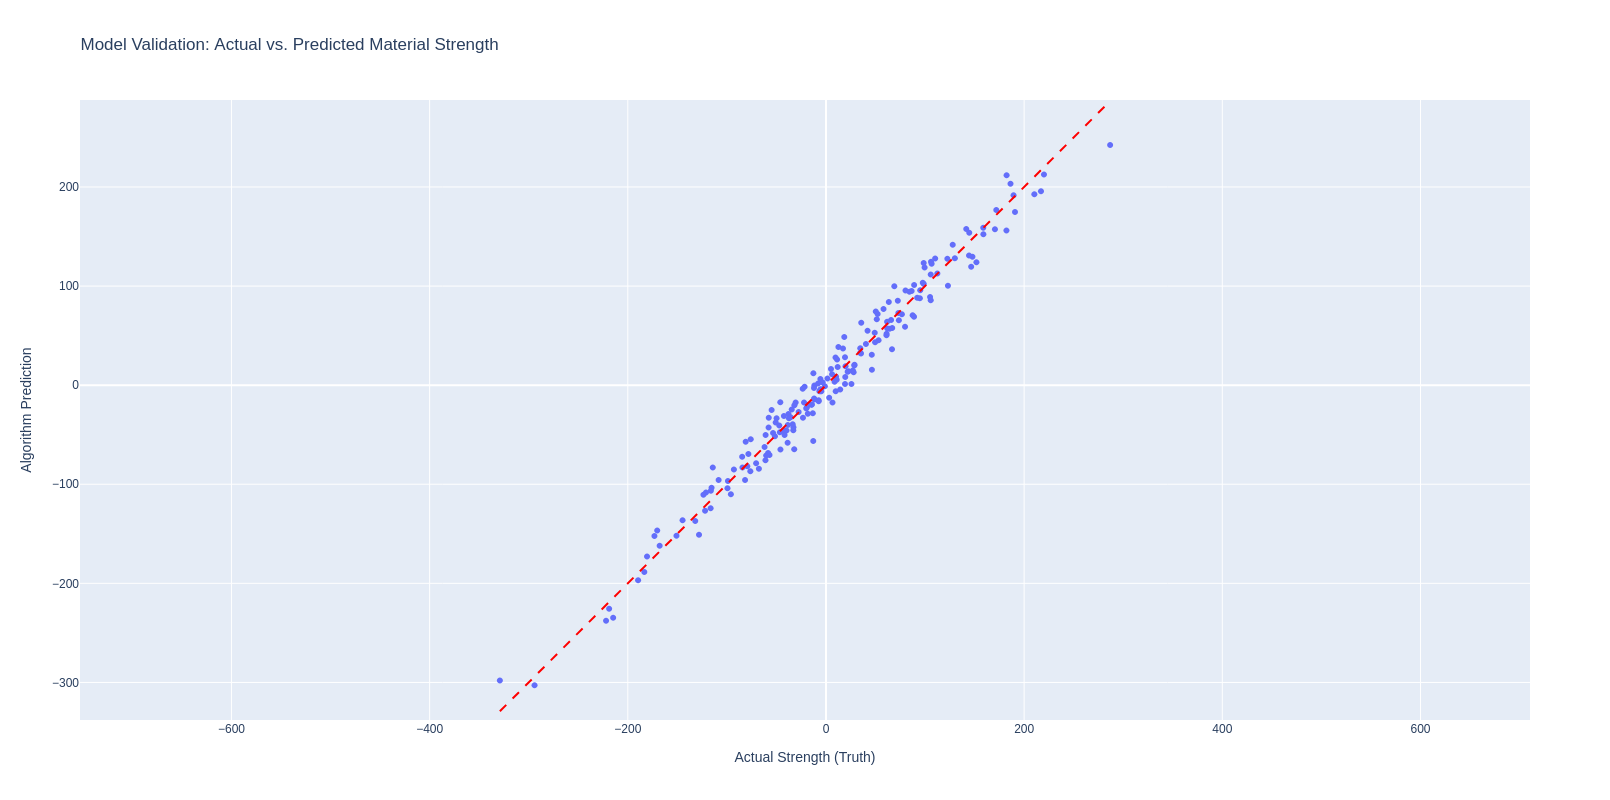

In [48]:
# 1. Train a basic Linear Regression model on all 5 features
model = LinearRegression()
model.fit(
    df_multi[["1D_Frag", "2D_Angle", "3D_Vol", "Density", "Temp"]],
    df_multi["Material_Strength"],
)

# 2. Generate predictions
df_multi["Predicted_Strength"] = model.predict(
    df_multi[["1D_Frag", "2D_Angle", "3D_Vol", "Density", "Temp"]]
)

# 3. The Validation Plot: Predicted vs. Actual
fig_val = px.scatter(
    df_multi,
    x="Material_Strength",
    y="Predicted_Strength",
    title="Model Validation: Actual vs. Predicted Material Strength",
    labels={
        "Material_Strength": "Actual Strength (Truth)",
        "Predicted_Strength": "Algorithm Prediction",
    },
)

# Add a perfect prediction line for reference
fig_val.add_shape(
    type="line",
    x0=df_multi["Material_Strength"].min(),
    y0=df_multi["Material_Strength"].min(),
    x1=df_multi["Material_Strength"].max(),
    y1=df_multi["Material_Strength"].max(),
    line=dict(color="Red", dash="dash"),
)
fig_val.update_layout(
    height=800,
    width=800,
    yaxis=dict(
        scaleanchor="x",
        scaleratio=1,
    ),
)
fig_val.show()

### The Algorithm as a Viewport
By plotting the **Predicted values vs. the Actual values** on a simple 2D plane, we collapse those 5 dimensions into something we can instantly understand. 

Because the dots closely follow the red dashed line (where Prediction exactly matches Actual), we have successfully validated our assumption: a linear model is highly effective at characterizing this 5-dimensional dataset. The Machine Learning algorithm acted as our mathematical viewport to "see" the multi-dimensional geometry!